# Validación de las métricas extendidas (Min-Subset fino, RRA + D-Minimal-Subset, Outside Box Deletion, letterbox_map_box)

Prueba sobre una muestra pequeña y aleatoria de objetos ya explicados por D-CRISP: 
comprobar que `refine_minimal_subset_k`, `rank_accuracy_at_k`, `outside_box_deletion` y
`letterbox_map_box` (`detection_metrics.py`/`common.py`) no
lanzan errores, devuelven valores no degenerados, y son coherentes con las métricas ya calculadas
y validadas (`relevance_rank_accuracy`, `minimal_subset`, `deletion_auc`, `insertion_auc`) para los mismos objetos.

In [12]:
import sys
import time
import warnings
warnings.filterwarnings("ignore")
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from tqdm import tqdm
from ultralytics import YOLO

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent
assert (REPO_ROOT / "pyproject.toml").exists(), f"Unexpected repo root: {REPO_ROOT}"

sys.path.insert(0, str(REPO_ROOT / "src"))
from xai_benchmark.evaluation import detection_metrics
from xai_benchmark.xai import common

CHECKPOINT = REPO_ROOT / "models/finetuned/best.pt"
VAL_IMAGES_DIR = REPO_ROOT / "data/kitti/images/val"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
CONF_THRES, IOU_THRES_NMS, STEP = 0.25, 0.5, 5000  # same frozen values as dcrisp.yaml

SEED = 0
np.random.seed(SEED)

In [13]:
model_dense = YOLO(str(CHECKPOINT))
model_prep = YOLO(str(CHECKPOINT))
model_dense.model.to(DEVICE)
model_dense.model.eval()
num_classes = model_dense.model.model[-1].nc

if getattr(model_prep, "predictor", None) is None:
    dummy = np.zeros((640, 640, 3), dtype=np.uint8)
    model_prep.predict([dummy], verbose=False, device=0 if DEVICE == "cuda" else "cpu")

print(f"Model uploaded in {DEVICE}. Classes: {num_classes}")

Model uploaded in cuda. Classes: 8


Usamos `results/dcrisp_a025/` como banco de pruebas: ya tiene `relevance_rank_accuracy`,
`minimal_subset`, `deletion_auc` e `insertion_auc` calculados para sus 2718 objetos, lo que
permite comparar las métricas nuevas contra algo ya validado, no solo comprobar que "no explota".
Muestreamos unas pocas **imágenes** (no objetos sueltos) para reutilizar el preprocesado por
imagen, igual que hace el bucle real de `run_evaluation.py`.

In [14]:
DCRISP_DIR = REPO_ROOT / "results/dcrisp_a025"

obj_df = pd.read_csv(DCRISP_DIR / "object_level.csv", dtype={"image_id": str})
eval_df = pd.read_csv(DCRISP_DIR / "eval_metrics.csv", dtype={"image_id": str})

N_IMAGES = 5
rng = np.random.default_rng(SEED)
sample_image_ids = rng.choice(obj_df["image_id"].unique(), size=N_IMAGES, replace=False)

sample_obj_df = obj_df[obj_df["image_id"].isin(sample_image_ids)].reset_index(drop=True)
print(f"Sampled images: {list(sample_image_ids)}")
print(f"Objects to validate: {len(sample_obj_df)}")

Sampled images: ['004957', '003898', '002011', '002236', '006322']
Objects to validate: 27


Verificación geométrica de `letterbox_map_box`: Antes de usarla dentro de las otras métricas, comprobamos la transformación en sí misma, sin
pasar por el modelo: mapeamos una caja al espacio letterboxed y deshacemos la transformación con
la aritmética inversa (mismo `gain`/`pad` que usa `unletterbox_map`), comprobando que se recupera
la caja original con un error de solo redondeo de punto flotante. Es una prueba puramente
algebraica.

In [5]:
max_roundtrip_error = 0.0
for _, row in sample_obj_df.iterrows():
    h0, w0 = int(row["letterbox_h"]), int(row["letterbox_w"])  # placeholder, corrected below
    box_orig = [row["x1"], row["y1"], row["x2"], row["y2"]]

for image_id in sample_image_ids:
    img_bgr = cv2.imread(str(VAL_IMAGES_DIR / f"{image_id}.png"))
    orig_shape = img_bgr.shape[:2]
    x_tensor = model_prep.predictor.preprocess([img_bgr]).to(DEVICE)
    letterbox_shape = tuple(x_tensor.shape[2:])
    h0, w0 = orig_shape
    h1, w1 = letterbox_shape
    gain = min(h1 / h0, w1 / w0)
    pad_x = round((w1 - round(w0 * gain)) / 2 - 0.1)
    pad_y = round((h1 - round(h0 * gain)) / 2 - 0.1)

    for _, row in sample_obj_df[sample_obj_df["image_id"] == image_id].iterrows():
        box_orig = [row["x1"], row["y1"], row["x2"], row["y2"]]
        box_lb = common.letterbox_map_box(box_orig, orig_shape, letterbox_shape)
        box_back = [(box_lb[0] - pad_x) / gain, (box_lb[1] - pad_y) / gain,
                    (box_lb[2] - pad_x) / gain, (box_lb[3] - pad_y) / gain]
        error = max(abs(a - b) for a, b in zip(box_orig, box_back))
        max_roundtrip_error = max(max_roundtrip_error, error)

print(f"Maximum round-trip error (pixels): {max_roundtrip_error:.2e}")
assert max_roundtrip_error < 1e-6, "letterbox_map_box is not consistent with unletterbox_map"

Maximum round-trip error (pixels): 5.68e-14


### Min-Subset fino, RRA + D-Minimal-Subset y Outside Box Deletion por objeto

Para cada objeto de la muestra: reconstruimos su heatmap en espacio letterboxed, montamos el
`DetectorAsClassifier`, recalculamos la curva de Deletion (igual que hace `run_evaluation.py`
para obtener `minimal_subset`), y a partir de ahí aplicamos las tres piezas nuevas:

- **Bracket + bisección**: derivamos `k_lo`/`k_hi` de la propia curva y refinamos con
  `refine_minimal_subset_k`. Comprobación dura: `k_lo <= k_exacto <= k_hi` siempre.
- **RRA + D-Minimal-Subset** (`rank_accuracy_at_k`): con el `k_exacto` recién calculado.
- **Outside Box Deletion** (`outside_box_deletion`): con la máscara de caja ya mapeada a espacio letterboxed
  (reutilizando la comprobación geométrica del paso 1).

Cualquier excepción se captura y se guarda con el `image_id`/`obj_idx` que la provocó, en vez de
frenar la muestra entera.

In [ ]:
rows, errors = [], []

for image_id in tqdm(sample_image_ids, desc="Validating objects"):
    img_bgr = cv2.imread(str(VAL_IMAGES_DIR / f"{image_id}.png"))
    orig_shape = img_bgr.shape[:2]
    x_tensor = model_prep.predictor.preprocess([img_bgr]).to(DEVICE)
    letterbox_shape = tuple(x_tensor.shape[2:])
    x_np = x_tensor.cpu().numpy().astype(np.float32)

    with np.load(DCRISP_DIR / f"heatmaps/{image_id}.npz") as npz:
        for _, row in sample_obj_df[sample_obj_df["image_id"] == image_id].iterrows():
            obj_idx = int(row["obj_idx"])
            target_box = [row["x1"], row["y1"], row["x2"], row["y2"]]
            target_class = int(row["pred_class"])

            try:
                heatmap_raw = npz[f"obj_{obj_idx}"]
                heatmap_lb = detection_metrics.reconstruct_heatmap_letterboxed(heatmap_raw, letterbox_shape)

                if np.all(heatmap_lb == heatmap_lb.flat[0]):
                    errors.append((image_id, obj_idx, "degenerate (constant) heatmap omitted"))
                    continue

                classifier = detection_metrics.DetectorAsClassifier(
                    model_dense, num_classes, orig_shape, target_box, target_class,
                    conf_thres=CONF_THRES, iou_thres_nms=IOU_THRES_NMS,
                )

                t0 = time.perf_counter()
                aucs = detection_metrics.deletion_insertion_auc(
                    classifier, x_np, heatmap_lb, target_class, step=STEP, device=DEVICE,
                )
                t_coarse = time.perf_counter() - t0

                scores_arr = np.asarray(aucs["deletion_scores"])
                below = np.flatnonzero(scores_arr < CONF_THRES)
                n_pixels_lb = letterbox_shape[0] * letterbox_shape[1]
                if below.size > 0:
                    k_hi = min(int(below[0]) * STEP, n_pixels_lb)
                    k_lo = max(k_hi - STEP, 0)
                else:
                    k_lo = k_hi = n_pixels_lb

                t0 = time.perf_counter()
                k_exact = detection_metrics.refine_minimal_subset_k(
                    x_np, heatmap_lb, classifier, target_class, k_lo, k_hi, CONF_THRES, device=DEVICE,
                )
                t_bisect = time.perf_counter() - t0
                assert k_lo <= k_exact <= k_hi, f"k_exact outside the bracket: {k_lo} <= {k_exact} <= {k_hi}"

                target_box_lb = common.letterbox_map_box(target_box, orig_shape, letterbox_shape)
                box_mask_lb = detection_metrics.build_box_mask(target_box_lb, *letterbox_shape)

                rank_acc = detection_metrics.rank_accuracy_at_k(heatmap_lb, box_mask_lb, k_exact)
                assert 0.0 <= rank_acc["rank_accuracy_box"] <= 1.0, f"RRA + D-Minimal-Subset (box) out of range: {rank_acc}"
                assert 0.0 <= rank_acc["rank_accuracy_precision"] <= 1.0, f"RRA + D-Minimal-Subset (precision) out of range: {rank_acc}"

                t0 = time.perf_counter()
                outside = detection_metrics.outside_box_deletion(
                    classifier, x_np, heatmap_lb, box_mask_lb, target_class, step=STEP, device=DEVICE,
                )
                t_outside = time.perf_counter() - t0

                stored = eval_df[(eval_df["image_id"] == image_id) & (eval_df["obj_idx"] == obj_idx)].iloc[0]

                rows.append({
                    "image_id": image_id, "obj_idx": obj_idx, "correctness": row["correctness"],
                    "k_exact": k_exact, "n_pixels_lb": n_pixels_lb,
                    "minimal_subset_stored": stored["minimal_subset"],
                    "minimal_subset_from_k_exact": k_exact / n_pixels_lb,
                    "rank_accuracy_at_min_subset": rank_acc["rank_accuracy_box"],
                    "rank_accuracy_precision": rank_acc["rank_accuracy_precision"],
                    "relevance_rank_accuracy_stored": stored["relevance_rank_accuracy"],
                    "outside_box_deletion_auc": outside["outside_box_deletion_auc"],
                    "outside_box_confidence_drop": outside["outside_box_confidence_drop"],
                    "deletion_auc_stored": stored["deletion_auc"],
                    "t_coarse_s": t_coarse, "t_bisect_s": t_bisect, "t_outside_s": t_outside,
                })
            except Exception as exc:
                errors.append((image_id, obj_idx, repr(exc)))

print(f"Objects validated without error: {len(rows)}/{len(sample_obj_df)}")
if errors:
    print("Incidents:")
    for image_id, obj_idx, msg in errors:
        print(f"  {image_id} obj_{obj_idx}: {msg}")

Validando objetos:   0%|          | 0/5 [00:00<?, ?it/s]

Validando objetos: 100%|██████████| 5/5 [03:01<00:00, 36.34s/it]

Objetos validados sin error: 27/27


Tabla por objeto (incluye `k_exact`, el tamaño exacto del subconjunto causal en píxeles, y
`n_pixels_lb` para poder interpretar qué fracción del frame representa) para conclusiones
individuales, y un resumen agregado (media/desviación/min/max sobre toda la muestra) para
conclusiones globales: discrepancia media Min-Subset fino vs. grueso, nivel medio de RRA + D-Minimal-Subset,
brecha media entre `outside_box_deletion_auc` y `deletion_auc`, y coste medio en tiempo por pieza.

In [ ]:
df_check = pd.DataFrame(rows)
df_check["minimal_subset_diff"] = (df_check["minimal_subset_from_k_exact"]
                                    - df_check["minimal_subset_stored"]).abs()

display_cols = ["image_id", "obj_idx", "correctness", "k_exact", "n_pixels_lb",
                 "minimal_subset_stored", "minimal_subset_from_k_exact", "minimal_subset_diff",
                 "rank_accuracy_at_min_subset", "rank_accuracy_precision", "relevance_rank_accuracy_stored",
                 "deletion_auc_stored", "outside_box_deletion_auc", "outside_box_confidence_drop",
                 "t_coarse_s", "t_bisect_s", "t_outside_s"]
                 
print(f"Results by object (n={len(df_check)}):")
display(df_check[display_cols])

summary_cols = [c for c in display_cols if c not in ("image_id", "obj_idx", "correctness")]
df_summary = df_check[summary_cols].agg(["mean", "std", "min", "max"]).T
print("\nSummary:")
display(df_summary)

corr = df_check["rank_accuracy_at_min_subset"].corr(df_check["relevance_rank_accuracy_stored"])
frac_expected = (df_check["outside_box_deletion_auc"] >= df_check["deletion_auc_stored"]).mean()
print(f"\nCorrelation RRA + D-Minimal-Subset vs. relevance_rank_accuracy already validated: {corr:.3f}")
print(f"Fraction of objects with outside_box_deletion_auc >= deletion_auc: {frac_expected:.2%}")
print(f"k_exact medio: {df_summary.loc['k_exact', 'mean']:.0f} px "
      f"({df_summary.loc['minimal_subset_from_k_exact', 'mean']:.4f} of the frame letterboxed)")

Resultados por objeto (n=27):


,image_id,obj_idx,correctness,k_exact,n_pixels_lb,minimal_subset_stored,minimal_subset_from_k_exact,minimal_subset_diff,rank_accuracy_at_min_subset,rank_accuracy_precision,relevance_rank_accuracy_stored,deletion_auc_stored,outside_box_deletion_auc,outside_box_confidence_drop,t_coarse_s,t_bisect_s,t_outside_s
0,004957,0,correct,11350,143360,0.103448,0.079171,0.024277,0.993056,0.050396,0.828450,0.052804,0.072293,0.910453,5.112044,0.826708,2.031078
1,004957,1,correct,635,143360,0.034483,0.004429,0.030053,0.970370,0.412598,0.770563,0.015630,0.071966,0.906524,4.031267,0.903590,1.832315
2,004957,2,correct,10915,143360,0.103448,0.076137,0.027311,0.880087,0.110948,0.705116,0.053289,0.631848,0.275238,4.165258,0.759557,1.810679
3,004957,3,false_positive,27502,143360,0.206897,0.191839,0.015058,0.967949,0.005491,0.301818,0.089930,0.015697,0.910453,3.583468,0.710004,1.891159
4,003898,0,correct,10942,143360,0.103448,0.076325,0.027123,0.777591,0.507403,0.662327,0.064387,0.934119,0.002566,3.173159,0.634571,1.564648
5,003898,1,correct,1122,143360,0.034483,0.007826,0.026656,0.280781,1.000000,0.564125,0.043338,0.200979,0.934437,3.257762,0.761078,1.465324
6,003898,2,correct,12584,143360,0.103448,0.087779,0.015669,0.802142,0.250000,0.660445,0.080912,0.860439,0.100330,3.310013,0.779898,2.504901
7,003898,3,correct,775,143360,0.034483,0.005406,0.029077,0.921569,0.242581,0.548295,0.012912,0.012912,0.748878,5.928300,1.258928,2.074711
8,003898,4,false_positive,7594,143360,0.068966,0.052972,0.015994,0.990300,0.147880,0.646667,0.048546,0.059669,0.941006,3.979249,0.855112,1.781905
9,003898,5,correct,289,143360,0.034483,0.002016,0.032467,0.023256,0.065744,0.027116,0.009583,0.009583,0.555790,3.683500,0.865836,1.841034



Resumen agregado:


,mean,std,min,max
k_exact,5436.555556,5924.724819,3.000000,27502.000000
n_pixels_lb,143360.000000,0.000000,143360.000000,143360.000000
minimal_subset_stored,0.057471,0.040576,0.034483,0.206897
minimal_subset_from_k_exact,0.037922,0.041328,0.000021,0.191839
minimal_subset_diff,0.019549,0.010141,0.000554,0.034462
rank_accuracy_at_min_subset,0.728356,0.307472,0.000000,0.993056
rank_accuracy_precision,0.310489,0.268599,0.000000,1.000000
relevance_rank_accuracy_stored,0.546363,0.245613,0.000000,0.828450
deletion_auc_stored,0.031004,0.023979,0.004975,0.089930
outside_box_deletion_auc,0.274976,0.322543,0.004975,0.934119



Correlación Metric A vs. relevance_rank_accuracy ya validada: 0.750
Fracción de objetos con outside_box_deletion_auc >= deletion_auc: 96.30%
k_exact medio: 5437 px (0.0379 del frame letterboxed)


Misma tabla y mismas columnas que la sección 3, pero para SSGrad-CAM++, sobre los mismos
`sample_image_ids`/objetos ya usados con D-CRISP. Cada objeto de
`sample_obj_df` (D-CRISP) se empareja con su correspondiente en `object_level.csv` de
SSGrad-CAM++ por IoU de caja (`>0.5`, mismo umbral que `matching.iou_thres_gt`), en vez de asumir
que `obj_idx` coincide entre los dos CSV.

In [8]:
SSGRADCAMPP_DIR = REPO_ROOT / "results/ssgradcampp"
obj_df_ss = pd.read_csv(SSGRADCAMPP_DIR / "object_level.csv", dtype={"image_id": str})


def iou_xyxy(b1, b2):
    x1, y1, x2, y2 = b1
    X1, Y1, X2, Y2 = b2
    ix1, iy1, ix2, iy2 = max(x1, X1), max(y1, Y1), min(x2, X2), min(y2, Y2)
    iw, ih = max(0, ix2 - ix1), max(0, iy2 - iy1)
    inter = iw * ih
    a1, a2 = (x2 - x1) * (y2 - y1), (X2 - X1) * (Y2 - Y1)
    return inter / (a1 + a2 - inter + 1e-9)


def match_object(image_id, target_box, other_df, iou_thres=0.5):
    cand = other_df[other_df.image_id == image_id]
    best_iou, best_row = 0.0, None
    for _, c in cand.iterrows():
        i = iou_xyxy(target_box, [c.x1, c.y1, c.x2, c.y2])
        if i > best_iou:
            best_iou, best_row = i, c
    return best_row if best_iou >= iou_thres else None


rows_ss, errors_ss = [], []

for image_id in tqdm(sample_image_ids, desc="Validating SSGrad-CAM++"):
    img_bgr = cv2.imread(str(VAL_IMAGES_DIR / f"{image_id}.png"))
    orig_shape = img_bgr.shape[:2]
    x_tensor = model_prep.predictor.preprocess([img_bgr]).to(DEVICE)
    letterbox_shape = tuple(x_tensor.shape[2:])
    x_np = x_tensor.cpu().numpy().astype(np.float32)

    with np.load(SSGRADCAMPP_DIR / f"heatmaps/{image_id}.npz") as npz:
        for _, row in sample_obj_df[sample_obj_df["image_id"] == image_id].iterrows():
            obj_idx_dcrisp = int(row["obj_idx"])
            target_box = [row["x1"], row["y1"], row["x2"], row["y2"]]
            target_class = int(row["pred_class"])

            try:
                match = match_object(image_id, target_box, obj_df_ss)
                if match is None:
                    errors_ss.append((image_id, obj_idx_dcrisp, "without correspondence in SSGrad-CAM++"))
                    continue
                obj_idx = int(match["obj_idx"])

                heatmap_raw = npz[f"obj_{obj_idx}"]
                heatmap_lb = detection_metrics.reconstruct_heatmap_letterboxed(heatmap_raw, letterbox_shape)
                if np.all(heatmap_lb == heatmap_lb.flat[0]):
                    errors_ss.append((image_id, obj_idx_dcrisp, "heatmap degenerate (constant), omitted"))
                    continue

                classifier = detection_metrics.DetectorAsClassifier(
                    model_dense, num_classes, orig_shape, target_box, target_class,
                    conf_thres=CONF_THRES, iou_thres_nms=IOU_THRES_NMS,
                )

                t0 = time.perf_counter()
                aucs = detection_metrics.deletion_insertion_auc(
                    classifier, x_np, heatmap_lb, target_class, step=STEP, device=DEVICE,
                )
                t_coarse = time.perf_counter() - t0

                scores_arr = np.asarray(aucs["deletion_scores"])
                below = np.flatnonzero(scores_arr < CONF_THRES)
                n_pixels_lb = letterbox_shape[0] * letterbox_shape[1]
                if below.size > 0:
                    k_hi = min(int(below[0]) * STEP, n_pixels_lb)
                    k_lo = max(k_hi - STEP, 0)
                else:
                    k_lo = k_hi = n_pixels_lb

                t0 = time.perf_counter()
                k_exact = detection_metrics.refine_minimal_subset_k(
                    x_np, heatmap_lb, classifier, target_class, k_lo, k_hi, CONF_THRES, device=DEVICE,
                )
                t_bisect = time.perf_counter() - t0
                assert k_lo <= k_exact <= k_hi

                target_box_lb = common.letterbox_map_box(target_box, orig_shape, letterbox_shape)
                box_mask_lb = detection_metrics.build_box_mask(target_box_lb, *letterbox_shape)
                rank_acc = detection_metrics.rank_accuracy_at_k(heatmap_lb, box_mask_lb, k_exact)
                assert 0.0 <= rank_acc["rank_accuracy_box"] <= 1.0, f"RRA + D-Minimal-Subset (box) out of range: {rank_acc}"
                assert 0.0 <= rank_acc["rank_accuracy_precision"] <= 1.0, f"RRA + D-Minimal-Subset (precision) out of range: {rank_acc}"

                t0 = time.perf_counter()
                outside = detection_metrics.outside_box_deletion(
                    classifier, x_np, heatmap_lb, box_mask_lb, target_class, step=STEP, device=DEVICE,
                )
                t_outside = time.perf_counter() - t0

                rows_ss.append({
                    "image_id": image_id, "obj_idx": obj_idx, "obj_idx_dcrisp": obj_idx_dcrisp,
                    "correctness": match["correctness"],
                    "k_exact": k_exact, "n_pixels_lb": n_pixels_lb,
                    "minimal_subset_from_k_exact": k_exact / n_pixels_lb,
                    "rank_accuracy_at_min_subset": rank_acc["rank_accuracy_box"],
                    "rank_accuracy_precision": rank_acc["rank_accuracy_precision"],
                    "deletion_auc": aucs["deletion_auc"],
                    "outside_box_deletion_auc": outside["outside_box_deletion_auc"],
                    "outside_box_confidence_drop": outside["outside_box_confidence_drop"],
                    "t_coarse_s": t_coarse, "t_bisect_s": t_bisect, "t_outside_s": t_outside,
                })
            except Exception as exc:
                errors_ss.append((image_id, obj_idx_dcrisp, repr(exc)))

df_ss = pd.DataFrame(rows_ss)
print(f"SSGrad-CAM++ -- objects validated without error: {len(df_ss)}/{len(sample_obj_df)}")
if errors_ss:
    for image_id, obj_idx_dcrisp, msg in errors_ss:
        print(f"  {image_id} obj_{obj_idx_dcrisp}: {msg}")

display(df_ss)

summary_cols_ss = [c for c in df_ss.columns if c not in ("image_id", "obj_idx", "obj_idx_dcrisp", "correctness")]
display(df_ss[summary_cols_ss].agg(["mean", "std", "min", "max"]).T)

Validating SSGrad-CAM++: 100%|██████████| 5/5 [01:29<00:00, 17.94s/it]

SSGrad-CAM++ -- objects validated without error: 27/27


,image_id,obj_idx,obj_idx_dcrisp,correctness,k_exact,n_pixels_lb,minimal_subset_from_k_exact,rank_accuracy_at_min_subset,rank_accuracy_precision,deletion_auc,outside_box_deletion_auc,outside_box_confidence_drop,t_coarse_s,t_bisect_s,t_outside_s
0,004957,0,0,correct,68793,143360,0.479862,0.628472,0.005262,0.376948,0.577111,0.910453,2.120480,0.373358,0.856529
1,004957,1,1,correct,68763,143360,0.479653,0.840741,0.003301,0.321893,0.505411,0.906524,1.742190,0.411199,0.847439
2,004957,2,2,correct,81539,143360,0.568771,0.758721,0.012804,0.488051,0.848736,0.275238,1.699503,0.342371,0.874108
3,004957,3,3,false_positive,75815,143360,0.528843,1.000000,0.002058,0.422159,0.463825,0.910453,1.720806,0.390831,0.822795
4,003898,0,0,correct,95521,143360,0.666302,0.616527,0.046084,0.602542,0.941646,0.002566,1.862754,0.365633,0.849070
5,003898,1,1,correct,790,143360,0.005511,0.197698,1.000000,0.100320,0.643034,0.934437,1.831300,0.430523,0.842908
6,003898,2,2,correct,95584,143360,0.666741,1.000000,0.041032,0.615237,0.910508,0.100330,1.849351,0.376805,0.878766
7,003898,3,3,correct,193,143360,0.001346,0.612745,0.647668,0.049955,0.486939,0.748878,1.853129,0.445113,0.912561
8,003898,4,4,false_positive,94319,143360,0.657917,1.000000,0.012023,0.594475,0.557183,0.941006,1.847541,0.377690,0.975104
9,003898,5,5,correct,254,143360,0.001772,0.272950,0.877953,0.037019,0.164905,0.555790,1.799324,0.392577,0.925073


,mean,std,min,max
k_exact,59230.222222,38067.425961,45.000000,104885.000000
n_pixels_lb,143360.000000,0.000000,143360.000000,143360.000000
minimal_subset_from_k_exact,0.413157,0.265537,0.000314,0.731620
rank_accuracy_at_min_subset,0.683529,0.269787,0.189815,1.000000
rank_accuracy_precision,0.231827,0.373731,0.002058,1.000000
deletion_auc,0.343019,0.215750,0.004975,0.615237
outside_box_deletion_auc,0.549030,0.242058,0.004975,0.941646
outside_box_confidence_drop,0.640056,0.340754,0.002566,0.941006
t_coarse_s,1.950069,0.290985,1.597601,2.805754
t_bisect_s,0.415025,0.059144,0.334233,0.613985


Mapas de calor de los casos más significativos

Casos seleccionados (6):


,image_id,obj_idx,correctness,motivo,rank_acc_divergence,rank_prec_divergence,k_gap_divergence,violation_dcrisp,violation_ssgc
3,004957,3,false_positive,incumple Metric B,0.032051,0.003433,0.337005,True,False
8,003898,4,false_positive,incumple Metric B,0.009700,0.135857,0.604946,False,True
21,006322,4,correct,incumple Metric B,0.065476,0.112732,0.574149,False,True
16,002236,3,false_positive,mayor desacuerdo en rank_accuracy_box (Metric A),0.590278,0.825243,0.000698,False,False
24,006322,7,correct,mayor desacuerdo en rank_accuracy_box (Metric A),0.537500,0.830470,0.012493,False,False
18,006322,1,false_positive,mayor desacuerdo en rank_accuracy_precision (M...,0.170266,0.934891,0.698284,False,False


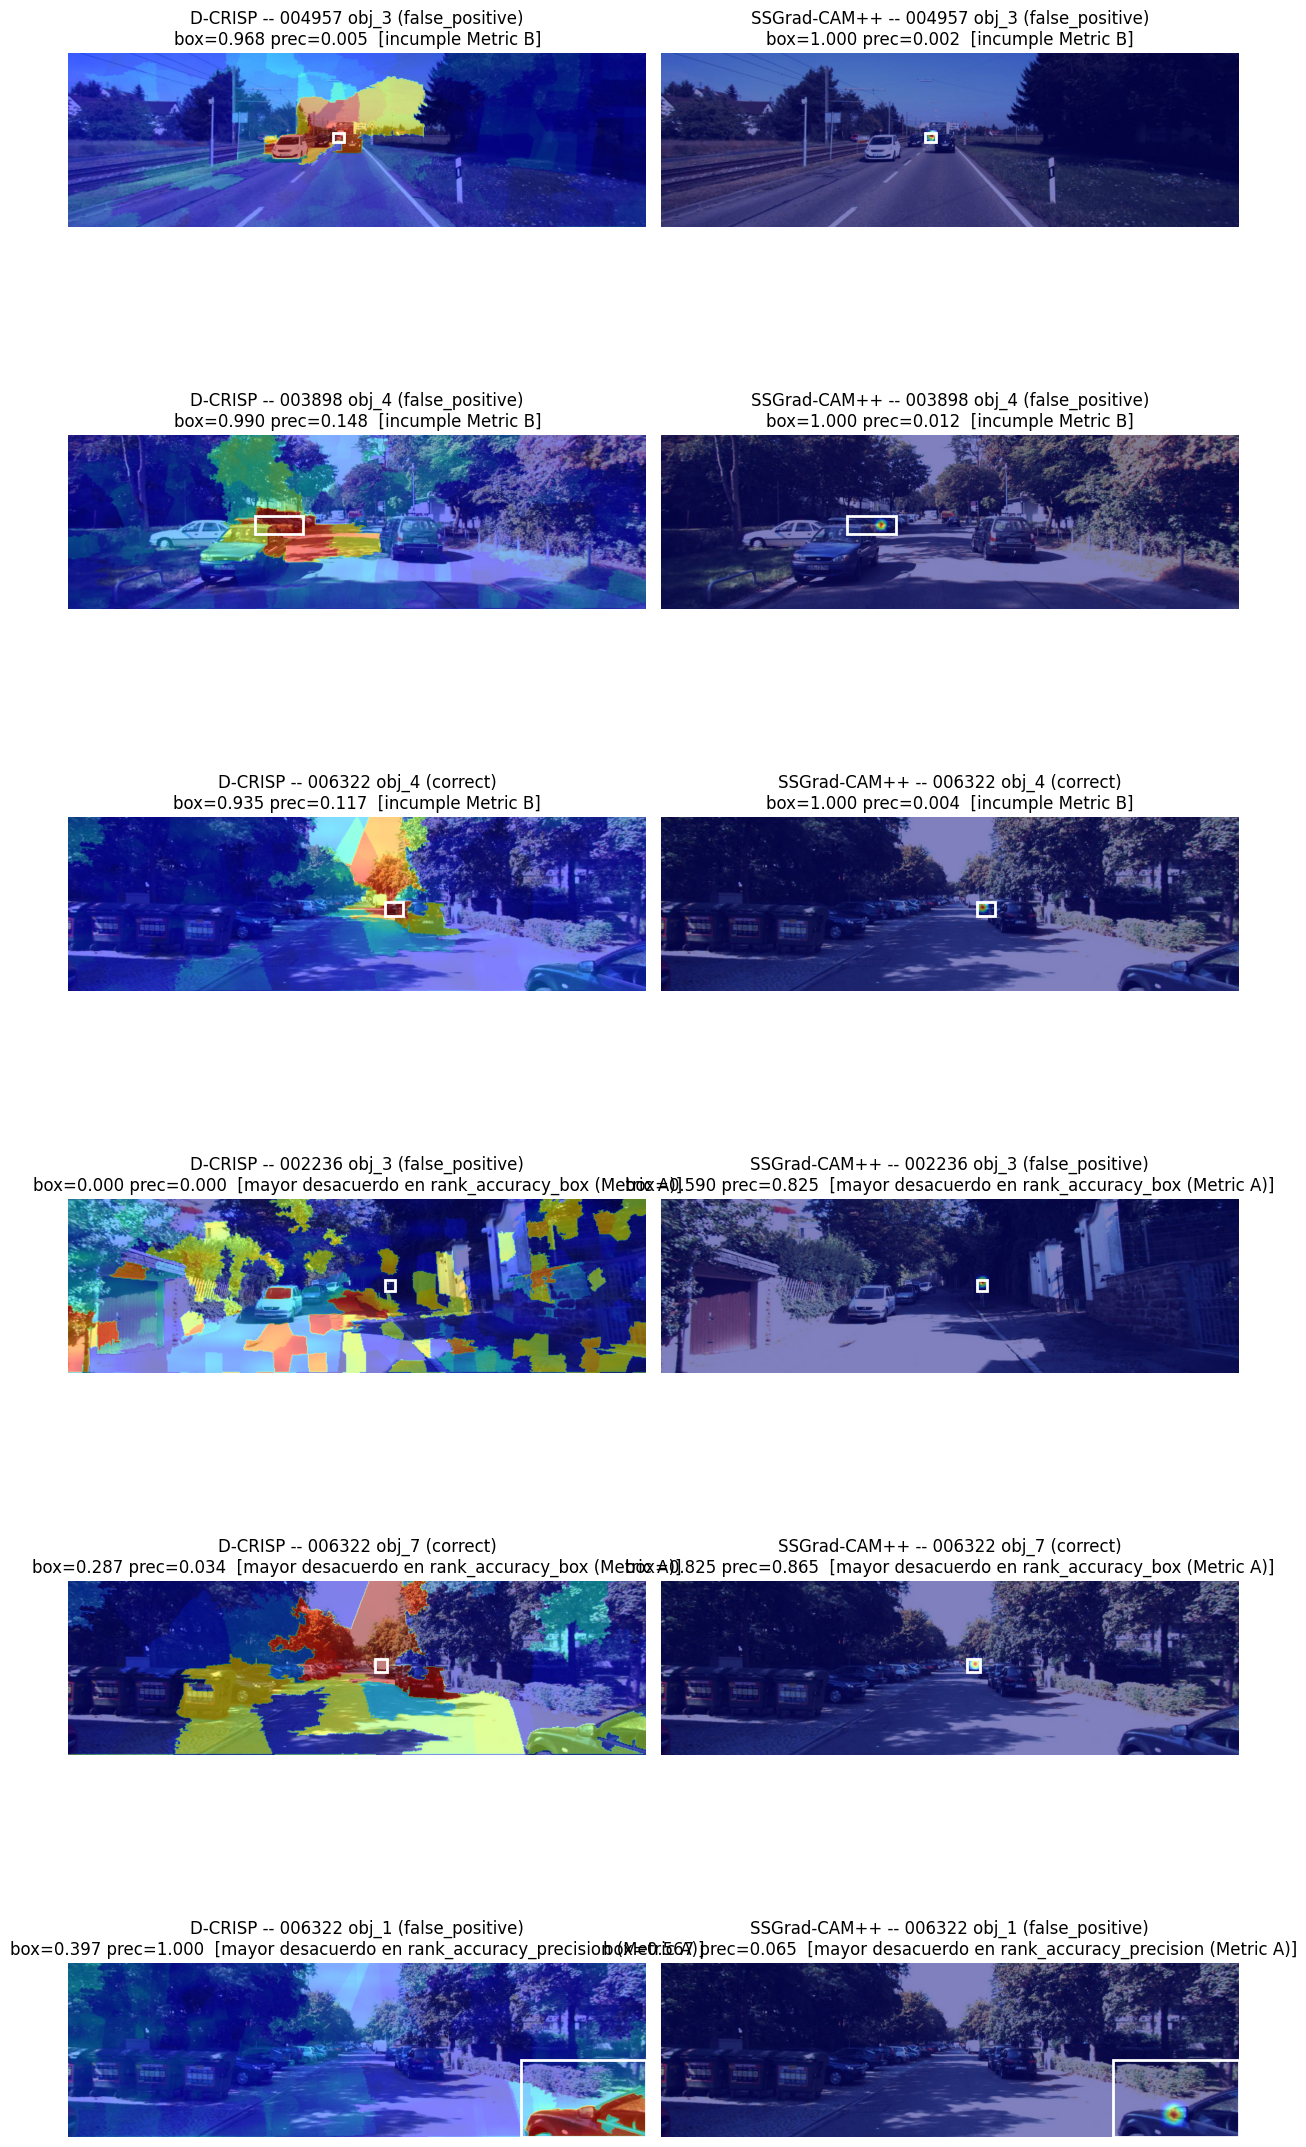

In [ ]:
pick = df_check.rename(columns={
    "rank_accuracy_at_min_subset": "rank_acc_dcrisp",
    "rank_accuracy_precision": "rank_prec_dcrisp",
    "outside_box_deletion_auc": "outside_auc_dcrisp",
    "deletion_auc_stored": "deletion_auc_dcrisp",
    "minimal_subset_from_k_exact": "ms_dcrisp",
})[["image_id", "obj_idx", "correctness", "rank_acc_dcrisp", "rank_prec_dcrisp",
    "outside_auc_dcrisp", "deletion_auc_dcrisp", "ms_dcrisp"]].merge(
    df_ss.rename(columns={
        "rank_accuracy_at_min_subset": "rank_acc_ssgc",
        "rank_accuracy_precision": "rank_prec_ssgc",
        "outside_box_deletion_auc": "outside_auc_ssgc",
        "deletion_auc": "deletion_auc_ssgc",
        "minimal_subset_from_k_exact": "ms_ssgc",
        "obj_idx": "obj_idx_ssgc",
    })[["image_id", "obj_idx_dcrisp", "obj_idx_ssgc", "rank_acc_ssgc", "rank_prec_ssgc",
        "outside_auc_ssgc", "deletion_auc_ssgc", "ms_ssgc"]],
    left_on=["image_id", "obj_idx"], right_on=["image_id", "obj_idx_dcrisp"],
).reset_index(drop=True)

pick["rank_acc_divergence"] = (pick["rank_acc_dcrisp"] - pick["rank_acc_ssgc"]).abs()
pick["rank_prec_divergence"] = (pick["rank_prec_dcrisp"] - pick["rank_prec_ssgc"]).abs()
pick["k_gap_divergence"] = (pick["ms_dcrisp"] - pick["ms_ssgc"]).abs()
pick["significance"] = pick["rank_acc_divergence"] + pick["rank_prec_divergence"] + pick["k_gap_divergence"]
pick["violation_dcrisp"] = pick["outside_auc_dcrisp"] < pick["deletion_auc_dcrisp"]
pick["violation_ssgc"] = pick["outside_auc_ssgc"] < pick["deletion_auc_ssgc"]

MIN_CASES, MAX_CASES = 5, 10
N_RANK_TOP, N_PREC_TOP, N_K_TOP = 2, 2, 2

selected_idx, reasons = [], {}

def add(index_list, reason):
    for idx in index_list:
        if idx not in selected_idx:
            selected_idx.append(idx)
            reasons[idx] = reason

add(pick[pick["violation_dcrisp"] | pick["violation_ssgc"]].index, "incumple Metric B")
add(pick.sort_values("rank_acc_divergence", ascending=False).head(N_RANK_TOP).index,
    "mayor desacuerdo en rank_accuracy_box (Metric A)")
add(pick.sort_values("rank_prec_divergence", ascending=False).head(N_PREC_TOP).index,
    "mayor desacuerdo en rank_accuracy_precision (Metric A)")
add(pick.sort_values("k_gap_divergence", ascending=False).head(N_K_TOP).index,
    "mayor desacuerdo en tamano del subconjunto causal")
if len(selected_idx) < MIN_CASES:
    for idx in pick.sort_values("significance", ascending=False).index:
        if idx not in selected_idx:
            add([idx], "relleno por significancia combinada")
        if len(selected_idx) >= MIN_CASES:
            break

selected_idx = selected_idx[:MAX_CASES]
selected = pick.loc[selected_idx].copy()
selected["motivo"] = [reasons[i] for i in selected_idx]

print(f"Selected cases ({len(selected)}):")
display(selected[["image_id", "obj_idx", "correctness", "motivo", "rank_acc_divergence",
                   "rank_prec_divergence", "k_gap_divergence", "violation_dcrisp", "violation_ssgc"]])

fig, axes = plt.subplots(len(selected), 2, figsize=(12, 4 * len(selected)))
if len(selected) == 1:
    axes = axes[None, :]

for row_i, (_, case) in enumerate(selected.iterrows()):
    image_id = case["image_id"]
    img_bgr = cv2.imread(str(VAL_IMAGES_DIR / f"{image_id}.png"))
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    orig_shape = img_bgr.shape[:2]
    x_tensor = model_prep.predictor.preprocess([img_bgr]).to(DEVICE)
    letterbox_shape = tuple(x_tensor.shape[2:])

    obj_row = sample_obj_df[(sample_obj_df.image_id == image_id)
                             & (sample_obj_df.obj_idx == case["obj_idx"])].iloc[0]
    target_box = [obj_row.x1, obj_row.y1, obj_row.x2, obj_row.y2]

    for col_i, (heatmap_dir, this_obj_idx, label, rank_acc, rank_prec) in enumerate([
        (DCRISP_DIR, case["obj_idx"], "D-CRISP", case["rank_acc_dcrisp"], case["rank_prec_dcrisp"]),
        (SSGRADCAMPP_DIR, case["obj_idx_ssgc"], "SSGrad-CAM++", case["rank_acc_ssgc"], case["rank_prec_ssgc"]),
    ]):
        with np.load(heatmap_dir / f"heatmaps/{image_id}.npz") as npz:
            heatmap_raw = npz[f"obj_{int(this_obj_idx)}"]
        heatmap_orig = detection_metrics.reconstruct_heatmap_original(heatmap_raw, letterbox_shape, orig_shape)

        ax = axes[row_i, col_i]
        ax.imshow(img_rgb)
        ax.imshow(heatmap_orig, cmap="jet", alpha=0.5)
        x1, y1, x2, y2 = target_box
        ax.add_patch(plt.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, edgecolor="white", linewidth=2))
        ax.set_title(f"{label} -- {image_id} obj_{case['obj_idx']} ({case['correctness']})\n"
                     f"box={rank_acc:.3f} prec={rank_prec:.3f}  [{case['motivo']}]")
        ax.axis("off")

plt.tight_layout()
plt.show()

## Conclusión

Objetivo de este notebook: comprobar que `refine_minimal_subset_k`, `rank_accuracy_at_k` y
`outside_box_deletion` (`detection_metrics.py`) funcionan sin errores y dan valores coherentes. 
Con eso en mente:

**Código:** validado sobre 27 objetos (5 imágenes), 0 errores, todas las comprobaciones duras
(`k_lo <= k_exacto <= k_hi`, rangos en `[0, 1]`) se cumplen. Coste extra por objeto más allá de lo
que ya paga `deletion_insertion_auc`: ~2.7 s (D-CRISP) / ~2.9 s (SSGrad-CAM++) -- referencia para
decidir aplicarlo a todos los objetos o a un subconjunto en las evaluaciones finales.

**Señales preliminares a vigilar en la evaluación completa, no conclusiones:**
D-CRISP necesita ~10x menos píxeles que SSGrad-CAM++ para tumbar la detección (Deletion mucho más
eficiente); `rank_accuracy_precision` revela que gran parte de esa brecha es mecánica (una vez
normalizada por el techo que impone el propio `k` de cada método, ambos rondan el 80% de su
óptimo); los dos métodos fallan en objetos distintos (`rank_accuracy_precision` cruzada ~0);
D-CRISP pierde precisión de ranking en falsos positivos, SSGrad-CAM++ no. Muestra pequeña (n=27,
5 falsos positivos) y no representativa (no extrapolar sin la ejecución completa).

## Validación de las métricas de robustez y estabilidad (Max-Sensitivity, RIS, ROS, RRS)

Objetivo: comprobar que `evaluate_perturbation_stability` (`stability.py`) funciona
correctamente sobre objetos reales.

Confirma que el código es correcto y da una primera referencia de coste, no
resultados representativos para conclusiones cuantitativas.

In [19]:
from xai_benchmark.detection.yolo_head import get_one2many_predictions
from xai_benchmark.uncertainty.tta import box_iou
from xai_benchmark.xai.dcrisp import DCRISP
from xai_benchmark.xai.ssgradcampp import SSGradCAMPP
from xai_benchmark.evaluation import stability

IOU_THRES_GT = 0.5  
N_SAMPLES_DCRISP = 5
N_SAMPLES_SSGC = 20    
RADIUS = 0.1         # Max_sensitivity's official paper

dcrisp_explainer = DCRISP.from_checkpoint(
    CHECKPOINT, device=DEVICE, conf_thres=CONF_THRES, iou_thres_nms=IOU_THRES_NMS,
    n_masks=500, alpha=0.25, resolution=16, p1=0.25, num_levels=5, gpu_batch=50,
)
ssgc_explainer = SSGradCAMPP.from_checkpoint(CHECKPOINT, device=DEVICE, iou_match_thres=0.999)

Se reutiliza un subconjunto pequeño de `sample_obj_df`: ejecutar la robustez sobre
las 27 muestras completas sería demasiado costoso para D-CRISP (cada muestra de estabilidad
recalcula el heatmap entero, `n_masks` pasadas por perturbación). Para
SSGrad-CAM++ se usa el objeto correspondiente en `results/ssgradcampp`, no el `obj_idx` de D-CRISP.

In [16]:
N_STAB = 10
stab_obj_df = sample_obj_df.sample(n=N_STAB, random_state=SEED).reset_index(drop=True)
print(f"Objects for robustness/stability testing: {len(stab_obj_df)}")
display(stab_obj_df[["image_id", "obj_idx", "pred_class", "correctness"]])

Objects for robustness/stability testing: 10


,image_id,obj_idx,pred_class,correctness
0,002011,2,6,correct
1,006322,7,1,correct
2,004957,1,0,correct
3,006322,0,0,correct
4,002236,2,0,correct
5,003898,4,0,false_positive
6,006322,6,0,correct
7,004957,0,0,correct
8,006322,2,0,correct
9,006322,3,0,correct


### Calibración del umbral de anclaje de SSGrad-CAM++ para robustez/estabilidad

Las cuatro métricas (Max-Sensitivity, RIS, ROS y RRS) comparten un mismo mecanismo: perturban
ligeramente la imagen de entrada (ruido uniforme, `radius=0.1`, valor del propio paper de
Max-Sensitivity) y comparan el heatmap resultante
con el original. Para SSGrad-CAM++, generar ese heatmap sobre la imagen perturbada pasa por
`_locate_anchor`, que exige encontrar, entre las anclas densas de la imagen perturbada, una que
reproduzca casi exactamente (`IoU >= iou_match_thres = 0.999`) la caja de la detección original
**sin perturbar**.

Ese umbral funciona bien en producción (`run_xai_explanations.py`): ahí, la caja y el ancla que la
reproduce provienen de la misma pasada del modelo sobre la misma imagen, coinciden casi al 100%
por construcción, no por casualidad. Pero aquí le pedimos algo distinto y mucho más difícil: que
una pasada del modelo sobre una imagen *ligeramente distinta* (la perturbada) reproduzca la
caja de la imagen *original* al 99,9%. Cualquier regresor de cajas, ante cualquier cambio de
entrada por pequeño que sea, se mueve algo.

Antes de decidir un valor nuevo, medimos primero hasta dónde llega realmente cada intento
fallido: `_locate_anchor` ya calcula, para cada rechazo, el mejor IoU alcanzado entre las anclas de
la misma clase (aunque no llegue al 0.999) (es el dato `best_iou_same_class` de
`AnchorNotFoundError`, que `stability.py` recoge en `rejected_explain_best_ious`). Con la
distribución completa de esos valores (200 muestras, los 10 objetos) elegimos un umbral menos
estricto, específico para esta prueba de robustez, sin tocar el 0.999 de producción, que ya
está validado y funciona bien donde se usa.

In [20]:
rejected_ious_pool = []
n_rejected_total = 0
n_rejected_no_iou = 0

for _, row in stab_obj_df.iterrows():
    image_id = row["image_id"]
    obj_idx_dcrisp = int(row["obj_idx"])
    target_box_dcrisp = [row["x1"], row["y1"], row["x2"], row["y2"]]

    match = match_object(image_id, target_box_dcrisp, obj_df_ss)
    if match is None:
        continue
    target_box_ss = [match.x1, match.y1, match.x2, match.y2]
    target_class_ss = int(match.pred_class)

    img_bgr = cv2.imread(str(VAL_IMAGES_DIR / f"{image_id}.png"))
    orig_shape = img_bgr.shape[:2]
    letterbox_shape = tuple(model_prep.predictor.preprocess([img_bgr]).to(DEVICE).shape[2:])

    result0_ss = ssgc_explainer.explain(img_bgr, target_box_ss, target_class_ss)
    heatmap0_ss = detection_metrics.reconstruct_heatmap_letterboxed(result0_ss.heatmap_raw, letterbox_shape)

    def explain_fn_ssgc_diag(img_perturbed, _b=target_box_ss, _c=target_class_ss):
        r = ssgc_explainer.explain(img_perturbed, _b, _c)
        return detection_metrics.reconstruct_heatmap_letterboxed(r.heatmap_raw, letterbox_shape)

    diag = stability.evaluate_perturbation_stability(
        explain_fn_ssgc_diag, model_dense, model_prep, img_bgr, orig_shape,
        target_box_ss, target_class_ss, heatmap0_ss,
        n_samples=N_SAMPLES_SSGC, radius=RADIUS, conf_thres=CONF_THRES,
        iou_thres_nms=IOU_THRES_NMS, iou_thres_gt=IOU_THRES_GT, seed=SEED + obj_idx_dcrisp,
    )
    n_rejected_total += diag["n_rejected_explain"]
    for v in diag["rejected_explain_best_ious"]:
        if v is None:
            n_rejected_no_iou += 1
        else:
            rejected_ious_pool.append(v)

rejected_ious_pool = np.array(rejected_ious_pool)
print(f"Total rejections: {n_rejected_total}  |  with registered IoU: {len(rejected_ious_pool)}  |  "
      f"without IoU: {n_rejected_no_iou}")
print(pd.Series(rejected_ious_pool).describe(percentiles=[.05, .25, .5, .75, .9, .95, .99]))

Total rejections: 194  |  with registered IoU: 194  |  without IoU: 0
count    194.000000
mean       0.940847
std        0.039821
min        0.711928
5%         0.870359
25%        0.927268
50%        0.952822
75%        0.967539
90%        0.974293
95%        0.979579
99%        0.985019
max        0.986034
dtype: float64


In [21]:
for cand in [0.999, 0.995, 0.99, 0.98, 0.97, 0.95, 0.90, 0.80, 0.70, 0.50]:
    accept_rate = (rejected_ious_pool >= cand).mean()
    print(f"threshold={cand:.3f}: {accept_rate:.1%} of the samples rejected today would be accepted")

threshold=0.999: 0.0% of the samples rejected today would be accepted
threshold=0.995: 0.0% of the samples rejected today would be accepted
threshold=0.990: 0.0% of the samples rejected today would be accepted
threshold=0.980: 5.2% of the samples rejected today would be accepted
threshold=0.970: 20.6% of the samples rejected today would be accepted
threshold=0.950: 55.2% of the samples rejected today would be accepted
threshold=0.900: 87.1% of the samples rejected today would be accepted
threshold=0.800: 98.5% of the samples rejected today would be accepted
threshold=0.700: 100.0% of the samples rejected today would be accepted
threshold=0.500: 100.0% of the samples rejected today would be accepted


Elegido `0.90`: es el punto donde el barrido muestra el mayor salto de aceptación por unidad de
relajación (55.2% en 0.95 -> 87.1% en 0.90; seguir bajando a 0.80 solo suma 11 puntos más), y
sigue siendo un criterio de solapamiento estricto. Con
~87% de aceptación, la mayoría de las 20 muestras por objeto quedan disponibles para el máximo
Monte Carlo de las cuatro métricas, en vez de basarse en un puñado de muestras sueltas. Se aplica
solo a `ssgc_explainer`, la instancia de esta sección. No afecta a `ssgradcampp.yaml` ni a los
resultados ya calculados en `results/ssgradcampp/`.

In [22]:
IOU_MATCH_THRES_STABILITY = 0.90  
ssgc_explainer = SSGradCAMPP.from_checkpoint(CHECKPOINT, device=DEVICE,
                                              iou_match_thres=IOU_MATCH_THRES_STABILITY)

Para cada objeto, por separado para D-CRISP y para SSGrad-CAM++ (un fallo en uno no descarta el
resultado del otro):

- **D-CRISP**: `explain_fn` es un cierre sobre `dcrisp_explainer.explain()`. D-CRISP necesita
  además el vector completo de probabilidades por clase de la detección original
  (`target_class_probs`), el cual no está en `object_level.csv`,
  se recupera re-detectando la imagen sin perturbar y emparejando por IoU (`>0.99`). D-CRISP es caja negra genuina: no tiene mecanismo de
  anclaje que pueda fallar, por eso `dcrisp_n_rejected_explain` debe ser siempre 0.
- **SSGrad-CAM++**: `explain_fn` y `representation_fn` (para RRS) son cierres sobre
  `ssgc_explainer.explain()` y `stability.ssgradcampp_representation()` respectivamente, ambos
  pasando el heatmap por `reconstruct_heatmap_letterboxed` para fijar su resolución.
  `ssgc_explainer` es, en este punto del notebook, la instancia recalibrada de la celda anterior
  (`iou_match_thres=IOU_MATCH_THRES_STABILITY=0.90`). Aquí sí puede
  fallar el anclaje, tanto en la detección base (si falla, el objeto entero se registra en
  `stab_errors` y sus campos `ssgc_*` quedan `NaN`) como en cualquier muestra perturbada (si falla,
  se cuenta individualmente en `ssgc_n_rejected_explain`, sin descartar el objeto si otras muestras
  sí funcionan).

`seed=SEED+obj_idx` da independencia real entre objetos manteniendo reproducibilidad.

In [23]:
stab_rows, stab_errors = [], []

for _, row in tqdm(stab_obj_df.iterrows(), total=len(stab_obj_df), desc="Robustness/stability"):
    image_id = row["image_id"]
    obj_idx_dcrisp = int(row["obj_idx"])
    target_box_dcrisp = [row["x1"], row["y1"], row["x2"], row["y2"]]
    target_class = int(row["pred_class"])
    obj_seed = SEED + obj_idx_dcrisp

    img_bgr = cv2.imread(str(VAL_IMAGES_DIR / f"{image_id}.png"))
    orig_shape = img_bgr.shape[:2]
    imgs_tensor0 = model_prep.predictor.preprocess([img_bgr]).to(DEVICE)
    letterbox_shape = tuple(imgs_tensor0.shape[2:])

    out_row = {"image_id": image_id, "obj_idx": obj_idx_dcrisp, "correctness": row["correctness"]}

    # --- D-CRISP ---
    t0_dcrisp = time.perf_counter()
    try:
        dets0 = get_one2many_predictions(model_dense, imgs_tensor0, [orig_shape],
                                          conf_thres=CONF_THRES, iou_thres=IOU_THRES_NMS)[0]
        target_box_t = torch.as_tensor([target_box_dcrisp], dtype=dets0.boxes.dtype, device=dets0.boxes.device)
        ious0 = box_iou(target_box_t, dets0.boxes).squeeze(0)
        best0 = int(ious0.argmax())
        assert float(ious0[best0]) > 0.99, "The original detection was not recovered upon re-detection"
        target_class_probs = dets0.class_probs[best0].detach().cpu()

        result0 = dcrisp_explainer.explain(img_bgr, [(target_box_dcrisp, target_class, target_class_probs)])[0]

        def explain_fn_dcrisp(img_perturbed, _b=target_box_dcrisp, _c=target_class, _p=target_class_probs):
            return dcrisp_explainer.explain(img_perturbed, [(_b, _c, _p)])[0].heatmap_raw

        stab_d = stability.evaluate_perturbation_stability(
            explain_fn_dcrisp, model_dense, model_prep, img_bgr, orig_shape,
            target_box_dcrisp, target_class, result0.heatmap_raw,
            n_samples=N_SAMPLES_DCRISP, radius=RADIUS, conf_thres=CONF_THRES,
            iou_thres_nms=IOU_THRES_NMS, iou_thres_gt=IOU_THRES_GT, seed=obj_seed,
        )
        out_row.update({
            "dcrisp_n_valid": stab_d["n_valid"], "dcrisp_n_rejected_gate": stab_d["n_rejected_gate"],
            "dcrisp_n_rejected_explain": stab_d["n_rejected_explain"],
            "dcrisp_max_sensitivity": stab_d["max_sensitivity"],
            "dcrisp_ris": stab_d["relative_input_stability"], "dcrisp_ros": stab_d["relative_output_stability"],
        })
    except Exception as e:
        stab_errors.append((image_id, obj_idx_dcrisp, "dcrisp", repr(e)))
        out_row.update({k: np.nan for k in
                         ["dcrisp_n_valid", "dcrisp_n_rejected_gate", "dcrisp_n_rejected_explain",
                          "dcrisp_max_sensitivity", "dcrisp_ris", "dcrisp_ros"]})
    out_row["dcrisp_time_s"] = time.perf_counter() - t0_dcrisp

    # --- SSGrad-CAM++ ---
    t0_ssgc = time.perf_counter()
    try:
        match = match_object(image_id, target_box_dcrisp, obj_df_ss)
        if match is None:
            raise RuntimeError("without correspondence in SSGrad-CAM++")
        target_box_ss = [match.x1, match.y1, match.x2, match.y2]
        target_class_ss = int(match.pred_class)

        result0_ss = ssgc_explainer.explain(img_bgr, target_box_ss, target_class_ss)
        heatmap0_ss = detection_metrics.reconstruct_heatmap_letterboxed(result0_ss.heatmap_raw, letterbox_shape)
        representation0 = ssgc_explainer._activations[result0_ss.scale_idx][
            0, :, result0_ss.row, result0_ss.col].detach().cpu().numpy()

        def explain_fn_ssgc(img_perturbed, _b=target_box_ss, _c=target_class_ss):
            r = ssgc_explainer.explain(img_perturbed, _b, _c)
            return detection_metrics.reconstruct_heatmap_letterboxed(r.heatmap_raw, letterbox_shape)

        def representation_fn_ssgc(img_perturbed, _b=target_box_ss, _c=target_class_ss):
            return stability.ssgradcampp_representation(ssgc_explainer, img_perturbed, orig_shape, _b, _c)

        stab_s = stability.evaluate_perturbation_stability(
            explain_fn_ssgc, model_dense, model_prep, img_bgr, orig_shape,
            target_box_ss, target_class_ss, heatmap0_ss,
            n_samples=N_SAMPLES_SSGC, radius=RADIUS, conf_thres=CONF_THRES,
            iou_thres_nms=IOU_THRES_NMS, iou_thres_gt=IOU_THRES_GT, seed=obj_seed,
            representation_fn=representation_fn_ssgc, representation=representation0,
        )
        out_row.update({
            "ssgc_n_valid": stab_s["n_valid"], "ssgc_n_rejected_gate": stab_s["n_rejected_gate"],
            "ssgc_n_rejected_explain": stab_s["n_rejected_explain"],
            "ssgc_max_sensitivity": stab_s["max_sensitivity"],
            "ssgc_ris": stab_s["relative_input_stability"], "ssgc_ros": stab_s["relative_output_stability"],
            "ssgc_rrs": stab_s["relative_representation_stability"], "ssgc_n_valid_rrs": stab_s["n_valid_rrs"],
            "ssgc_n_rejected_representation": stab_s["n_rejected_representation"],
        })
    except Exception as e:
        stab_errors.append((image_id, obj_idx_dcrisp, "ssgradcampp", repr(e)))
        out_row.update({k: np.nan for k in
                         ["ssgc_n_valid", "ssgc_n_rejected_gate", "ssgc_n_rejected_explain",
                          "ssgc_max_sensitivity", "ssgc_ris", "ssgc_ros", "ssgc_rrs",
                          "ssgc_n_valid_rrs", "ssgc_n_rejected_representation"]})
    out_row["ssgc_time_s"] = time.perf_counter() - t0_ssgc

    stab_rows.append(out_row)

df_stab_tmp = pd.DataFrame(stab_rows)
print(f"Valid D-CRISP: {df_stab_tmp['dcrisp_n_valid'].notna().sum()}/{len(df_stab_tmp)}  |  "
      f"Valid SSGrad-CAM++: {df_stab_tmp['ssgc_n_valid'].notna().sum()}/{len(df_stab_tmp)}")
if stab_errors:
    print("\nErrors recorded (may be expected rejections):")
    for e in stab_errors:
        print(" ", e)

Robustness/stability:   0%|          | 0/10 [00:00<?, ?it/s]

Robustness/stability: 100%|██████████| 10/10 [42:10<00:00, 253.09s/it]

Valid D-CRISP: 10/10  |  Valid SSGrad-CAM++: 10/10


Tabla por objeto y resumen agregado. Dos comprobaciones duras: `dcrisp_n_rejected_explain` debe
ser siempre 0 y ninguna métrica puede ser negativa.

In [27]:
df_stab = pd.DataFrame(stab_rows)
df_stab.to_csv(REPO_ROOT / "notebooks/stab_results.csv", index=False)

dcrisp_rejects = df_stab["dcrisp_n_rejected_explain"].dropna()
assert (dcrisp_rejects == 0).all(), (
    "D-CRISP should never reject by explain_fn (it has no anchoring mechanism)"
)
for col in ["dcrisp_max_sensitivity", "dcrisp_ris", "dcrisp_ros",
            "ssgc_max_sensitivity", "ssgc_ris", "ssgc_ros", "ssgc_rrs"]:
    vals = df_stab[col].dropna()
    assert (vals >= 0).all(), f"{col} has negative values"

print(f"Objects: {len(df_stab)}  (Valid D-CRISP: {df_stab['dcrisp_n_valid'].notna().sum()}, "
      f"Valid SSGrad-CAM++: {df_stab['ssgc_n_valid'].notna().sum()})")
display(df_stab)

print("\nSummary:")
display(df_stab.drop(columns=["image_id", "obj_idx", "correctness"]).agg(["mean", "std", "min", "max"]).T)

time_per_image = df_stab.groupby("image_id")[["dcrisp_time_s", "ssgc_time_s"]].sum()
print("Time per image (s):")
display(time_per_image)

N_IMAGES_VAL = 1493  
N_OBJECTS_VAL = 8051
for method, col in [("D-CRISP", "dcrisp_time_s"), ("SSGrad-CAM++", "ssgc_time_s")]:
    mean_t_obj = df_stab[col].mean()
    total_h = mean_t_obj * N_OBJECTS_VAL / 3600
    print(f"{method}: {mean_t_obj:.1f} s/object -> extrapolated to {N_OBJECTS_VAL} objects "
          f"({N_IMAGES_VAL} images): {total_h:.1f} h")
print(f"\nNOTE: per-object extrapolation (this test's density = "
      f"{len(df_stab) / df_stab['image_id'].nunique():.2f} obj/img, "
      f"population's = {N_OBJECTS_VAL / N_IMAGES_VAL:.2f} obj/img)")

Objects: 10  (Valid D-CRISP: 10, Valid SSGrad-CAM++: 10)


,image_id,obj_idx,correctness,dcrisp_n_valid,dcrisp_n_rejected_gate,dcrisp_n_rejected_explain,dcrisp_max_sensitivity,dcrisp_ris,dcrisp_ros,dcrisp_time_s,ssgc_n_valid,ssgc_n_rejected_gate,ssgc_n_rejected_explain,ssgc_max_sensitivity,ssgc_ris,ssgc_ros,ssgc_rrs,ssgc_n_valid_rrs,ssgc_n_rejected_representation,ssgc_time_s
0,002011,2,correct,5,0,0,193.091751,6.389309e-02,3.622977e+08,185.199265,14,0,6,6.367529e-07,4.590737e-15,2.295119e-05,1.116422e-07,14,0,7.395604
1,006322,7,correct,5,0,0,191.570358,2.074995e-04,7.461979e+06,219.013757,18,0,2,9.116285e+00,1.319808e-02,1.000485e+09,1.742352e+05,18,0,10.584433
2,004957,1,correct,5,0,0,75.712395,7.255073e-07,1.577734e+05,217.453443,20,0,0,7.457475e-07,5.098424e-15,2.112792e-03,1.629837e-06,20,0,10.876991
3,006322,0,correct,5,0,0,50.607784,2.859721e-07,2.637608e+04,219.778438,20,0,0,1.244658e+01,2.124505e-02,1.428637e+09,3.264766e+04,20,0,11.383943
4,002236,2,correct,3,2,0,70.940414,1.066556e-06,1.181641e+03,145.795196,2,6,12,4.805552e-07,4.313849e-15,4.470026e-06,1.044031e-07,2,0,4.074741
5,003898,4,false_positive,5,0,0,67.712715,2.278875e-07,4.945021e+04,217.592112,19,0,1,8.270164e+00,7.302035e-03,8.576772e+08,5.639837e+05,19,0,10.750654
6,006322,6,correct,5,0,0,65.310081,3.601119e-07,6.336024e+03,247.362265,16,0,4,8.270165e+00,1.006336e-02,2.316367e+09,1.325625e+06,16,0,12.023544
7,004957,0,correct,5,0,0,56.990017,4.358098e-07,1.379483e+05,348.633081,20,0,0,7.388373e+00,1.032820e-02,1.121981e+09,3.356165e+05,20,0,13.102180
8,006322,2,correct,5,0,0,66.638718,2.848190e-07,1.605061e+04,317.115689,20,0,0,1.389998e+01,1.463301e-02,8.489332e+07,8.146351e+04,20,0,16.763206
9,006322,3,correct,5,0,0,74.293976,4.361223e-07,5.393186e+04,305.815429,20,0,0,1.138072e-06,6.375858e-15,9.376585e-04,1.647749e-06,20,0,10.122139



Summary:


,mean,std,min,max
dcrisp_n_valid,4.800000e+00,6.324555e-01,3.000000e+00,5.000000e+00
dcrisp_n_rejected_gate,2.000000e-01,6.324555e-01,0.000000e+00,2.000000e+00
dcrisp_n_rejected_explain,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
dcrisp_max_sensitivity,9.128682e+01,5.378500e+01,5.060778e+01,1.930918e+02
dcrisp_ris,6.410441e-03,2.019745e-02,2.278875e-07,6.389309e-02
dcrisp_ros,3.702087e+07,1.143143e+08,1.181641e+03,3.622977e+08
dcrisp_time_s,2.423759e+02,6.308272e+01,1.457952e+02,3.486331e+02
ssgc_n_valid,1.690000e+01,5.626327e+00,2.000000e+00,2.000000e+01
ssgc_n_rejected_gate,6.000000e-01,1.897367e+00,0.000000e+00,6.000000e+00
ssgc_n_rejected_explain,2.500000e+00,3.922867e+00,0.000000e+00,1.200000e+01


Time per image (s):


,dcrisp_time_s,ssgc_time_s
image_id,,
002011,185.199265,7.395604
002236,145.795196,4.074741
003898,217.592112,10.750654
004957,566.086525,23.979171
006322,1309.085577,60.877264


D-CRISP: 242.4 s/object -> extrapolated to 8051 objects (1493 images): 542.0 h
SSGrad-CAM++: 10.7 s/object -> extrapolated to 8051 objects (1493 images): 23.9 h

NOTE: per-object extrapolation (this test's density = 2.00 obj/img, population's = 5.39 obj/img)


¿la bimodalidad de SSGrad-CAM++ se debe a un cambio de celda-ancla? El heatmap de SSGrad-CAM++ depende de una única celda-ancla
(`scale_idx`/`row`/`col`). Si la perturbación no desplaza la detección a otra celda, el heatmap
debería cambiar poco o nada; si la desplaza, debería cambiar de forma abrupta. Se reproduce, para
los mismos 10 objetos y con el mismo `seed` que la ejecución real, cada una de las 20 muestras
perturbadas por objeto, registrando si la celda-ancla coincide con la original y la sensibilidad
del heatmap en ambos casos.

In [ ]:
rows_cell_diag = []

for _, row in stab_obj_df.iterrows():
    image_id = row["image_id"]
    obj_idx_dcrisp = int(row["obj_idx"])
    target_box_dcrisp = [row["x1"], row["y1"], row["x2"], row["y2"]]

    match = match_object(image_id, target_box_dcrisp, obj_df_ss)
    if match is None:
        continue
    target_box_ss = [match.x1, match.y1, match.x2, match.y2]
    target_class_ss = int(match.pred_class)

    img_bgr = cv2.imread(str(VAL_IMAGES_DIR / f"{image_id}.png"))
    orig_shape = img_bgr.shape[:2]
    letterbox_shape = tuple(model_prep.predictor.preprocess([img_bgr]).shape[2:])

    result0 = ssgc_explainer.explain(img_bgr, target_box_ss, target_class_ss)
    heatmap0 = detection_metrics.reconstruct_heatmap_letterboxed(result0.heatmap_raw, letterbox_shape)
    cell0 = (result0.scale_idx, result0.row, result0.col)

    rng = np.random.default_rng(SEED + obj_idx_dcrisp)
    for sample_idx in range(N_SAMPLES_SSGC):
        img_perturbed = stability._perturb_image_uniform(img_bgr, RADIUS, rng)

        h_x_perturbed = stability._matched_confidence(
            model_dense, model_prep, img_perturbed, orig_shape, target_box_ss, target_class_ss,
            CONF_THRES, IOU_THRES_NMS, IOU_THRES_GT,
        )
        if h_x_perturbed == 0.0:
            continue 

        try:
            result_p = ssgc_explainer.explain(img_perturbed, target_box_ss, target_class_ss)
        except Exception:
            continue 

        heatmap_p = detection_metrics.reconstruct_heatmap_letterboxed(result_p.heatmap_raw, letterbox_shape)
        cell_p = (result_p.scale_idx, result_p.row, result_p.col)

        rows_cell_diag.append({
            "image_id": image_id, "obj_idx": obj_idx_dcrisp, "sample_idx": sample_idx,
            "same_cell": cell_p == cell0,
            "sensitivity": float(np.linalg.norm(heatmap0 - heatmap_p)),
        })

diag_cell_df = pd.DataFrame(rows_cell_diag)
print(f"Samples compared: {len(diag_cell_df)}")
print(diag_cell_df.groupby("same_cell")["sensitivity"].agg(["count", "mean", "median", "std"]))
print("\nPer object, fraction of samples that keep the original anchor cell:")
print(diag_cell_df.groupby(["image_id", "obj_idx"])["same_cell"].mean())

Samples compared: 169
           count          mean        median           std
same_cell                                                 
False         45  1.003101e+01  9.116284e+00  2.383761e+00
True         124  5.423692e-07  4.700394e-07  2.196419e-07

Per object, fraction of samples that keep the original anchor cell:
image_id  obj_idx
002011    2          1.000000
002236    2          1.000000
003898    4          0.894737
004957    0          0.850000
          1          1.000000
006322    0          0.100000
          2          0.900000
          3          1.000000
          6          0.062500
          7          0.722222
Name: same_cell, dtype: float64


De las 200 muestras posibles (10 objetos ×
20 perturbaciones), 169 llegan a compararse (el resto se descartó antes, por el gate compartido
o por el umbral de anclaje). Separación limpia entre dos grupos, sin solapamiento: las 124
muestras que **mantienen** la celda-ancla original tienen sensibilidad media `5.4e-7` (ruido
numérico); las 45 que la **cambian** tienen media `10.03` -- una diferencia de ~7 órdenes de
magnitud. Confirma que la sensibilidad de SSGrad-CAM++ es, en la práctica, binaria: "cambia de
celda o no", no una magnitud continua.


Comprobación de coherencia adicional: al crecer el radio de
perturbación, el peor caso observado (Max-Sensitivity/RIS, aproximado por Monte Carlo) no debería,
en promedio, volverse más pequeño. No es una garantía estricta con `n_samples` reducido se trata como señal a inspeccionar, no como `assert`
duro. Solo sobre SSGrad-CAM++ ya que repetirlo con D-CRISP multiplicaría el coste por el número
de radios probados.

In [26]:
radii_to_test = [0.02, 0.05, 0.10, 0.20, 0.30]
row = stab_obj_df.iloc[0]
image_id = row["image_id"]
target_box_dcrisp = [row["x1"], row["y1"], row["x2"], row["y2"]]

match = match_object(image_id, target_box_dcrisp, obj_df_ss)
assert match is not None, "the reference object has no correspondence in SSGrad-CAM++"
target_box = [match.x1, match.y1, match.x2, match.y2]
target_class = int(match.pred_class)

img_bgr = cv2.imread(str(VAL_IMAGES_DIR / f"{image_id}.png"))
orig_shape = img_bgr.shape[:2]
letterbox_shape = tuple(model_prep.predictor.preprocess([img_bgr]).shape[2:])

result0 = ssgc_explainer.explain(img_bgr, target_box, target_class)
heatmap0 = detection_metrics.reconstruct_heatmap_letterboxed(result0.heatmap_raw, letterbox_shape)

def explain_fn_mono(img_perturbed, _b=target_box, _c=target_class):
    r = ssgc_explainer.explain(img_perturbed, _b, _c)
    return detection_metrics.reconstruct_heatmap_letterboxed(r.heatmap_raw, letterbox_shape)

print(f"Reference object: {image_id} (SSGrad-CAM++ obj {int(match.obj_idx)})")
for r in radii_to_test:
    res = stability.evaluate_perturbation_stability(
        explain_fn_mono, model_dense, model_prep, img_bgr, orig_shape,
        target_box, target_class, heatmap0,
        n_samples=N_SAMPLES_SSGC, radius=r, conf_thres=CONF_THRES,
        iou_thres_nms=IOU_THRES_NMS, iou_thres_gt=IOU_THRES_GT, seed=SEED,
    )
    print(f"  radius={r:.2f}: n_valid={res['n_valid']:>2}/{N_SAMPLES_SSGC}  "
          f"max_sensitivity={res['max_sensitivity']:.4f}  RIS={res['relative_input_stability']:.4f}  "
          f"n_rejected_gate={res['n_rejected_gate']}  n_rejected_explain={res['n_rejected_explain']}")

Reference object: 002011 (SSGrad-CAM++ obj 2)
  radius=0.02: n_valid=20/20  max_sensitivity=0.0000  RIS=0.0000  n_rejected_gate=0  n_rejected_explain=0
  radius=0.05: n_valid=20/20  max_sensitivity=0.0000  RIS=0.0000  n_rejected_gate=0  n_rejected_explain=0
  radius=0.10: n_valid=14/20  max_sensitivity=8.2702  RIS=0.0128  n_rejected_gate=0  n_rejected_explain=6
  radius=0.20: n_valid= 1/20  max_sensitivity=8.2702  RIS=0.0064  n_rejected_gate=16  n_rejected_explain=3
  radius=0.30: n_valid= 0/20  max_sensitivity=nan  RIS=nan  n_rejected_gate=20  n_rejected_explain=0


## Conclusión

Objetivo de esta sección: comprobar que `evaluate_perturbation_stability` (`stability.py`)
funciona correctamente para Max-Sensitivity, RIS, ROS y RRS, sobre D-CRISP y SSGrad-CAM++, con
datos reales. Con eso en mente:

**Código:** validado sobre 10 objetos reales. D-CRISP: 0 rechazos por `explain_fn` en las 10
(no tiene mecanismo de anclaje que pueda fallar, tal como debía). SSGrad-CAM++: tras recalibrar
`iou_match_thres` a 0.90 para esta sección, 84.5% de aceptación media.
 Las cuatro métricas dan valores numéricos reales, no `NaN`,
en los objetos con muestras válidas.

**Radio de perturbación:** utilizamos `radius=0.1`, el valor del propio paper de Max-Sensitivity. La comprobación de monotonicidad sobre un
objeto de referencia (`002011`, obj 2) confirma que 0.1 es el punto de equilibrio correcto: a
0.02 y 0.05 la señal es degenerada (`max_sensitivity=RIS=0.0000`, 20/20 válidas y el ruido es
demasiado pequeño para mover el heatmap de forma medible), a 0.10 la señal ya es real y no
trivial (`max_sensitivity=8.27`, `RIS=0.0128`, 14/20 válidas, 0 rechazos por el gate compartido);
a 0.20 y 0.30 el propio gate compartido (IoU+clase, no el de anclaje) empieza a colapsar (16/20 y
20/20 muestras rechazadas respectivamente), porque una perturbación de esa magnitud ya hace perder
la detección con frecuencia. El estancamiento del valor entre 0.10 y 0.20 (mismo
`max_sensitivity`, RIS menor) no es una violación de la monotonicidad esperada: a 0.20 solo
sobrevive 1/20 muestras, y un máximo sobre una sola muestra no es una estimación Monte Carlo
comparable a la de 14 muestras, es la señal de tamaño de muestra insuficiente que la celda
anterior ya anticipaba, no un fallo del código.

**Umbral de anclaje SSGrad-CAM++:** el fallo original (100% de rechazo a `iou_match_thres=0.999`)
se debía a que ese valor está calibrado para producción (misma pasada del modelo, misma imagen),
no para esta prueba (pasada sobre imagen *perturbada* debe reproducir la caja de la imagen
*original*). Se recalibró empíricamente a `IOU_MATCH_THRES_STABILITY=0.90` (mayor salto de
aceptación por unidad de relajación en el barrido), aplicado solo a `ssgc_explainer` de esta
sección. No afecta a `ssgradcampp.yaml` ni a `results/ssgradcampp/`.

**Mecanismo detrás de la bimodalidad de SSGrad-CAM++, verificado.** Una comprobación aparte
(reproduciendo con el mismo `seed`/`RADIUS` las 200 muestras de la ejecución anterior y registrando
la celda-ancla `(scale_idx, row, col)` de cada una) confirma la hipótesis: de 169 muestras
comparables, las que mantienen la celda original (124, 73.4%) tienen sensibilidad media `5.4e-7`
(ruido numérico); las que la cambian (45, 26.6%) tienen sensibilidad media `10.03` y coincide exactamente objeto por objeto
con la clasificación "sin cambio"/"con cambio real" ya hecha. Basta que una sola de las
`n_samples` muestras cruce el límite de celda (no la mayoría) para que el máximo del objeto sea
grande, lo que conecta directamente con la asimetría de muestreo `n_samples=20` (SSGrad-CAM++) vs.
`n_samples=5` (D-CRISP) ya documentada: cada muestra adicional es, en la práctica, una oportunidad
más de cruzar ese límite. Importante para la interpretación: esto confirma una inestabilidad real
en la asignación de ancla del modelo entre candidatos densos, pero no equivale a que la detección
final (caja/confianza, ya filtrada por el gate compartido de IoU≥0.5) sea inestable, ni es
necesariamente una propiedad del modelo independiente del método explicativo El heatmap de
SSGrad-CAM++ está atado por diseño a una única celda, así que su sensibilidad es en buena medida
sensibilidad de "qué celda gana", un patrón que un método con heatmap agregado (como D-CRISP) no
tendría por qué reproducir ante la misma inestabilidad subyacente.

**Integración en producción.** 

- *Dos umbrales de anclaje, no uno.* La razón de fondo del 100% de rechazo a 0.999 no desaparece en
  producción: `run_xai_explanations.py` seguirá generando `object_level.csv` con `0.999` (régimen
  fácil, misma pasada del modelo, 0 fallos ya comprobados sobre los 8051 objetos completos), y el
  nuevo paso de robustez en `run_evaluation.py` usará una segunda instancia de `SSGradCAMPP` con
  `0.90` (el valor calibrado aquí), solo para `explain_fn`/`representation_fn` sobre imágenes
  perturbadas. Bajar el `0.999` de producción a `0.90` de forma global se descarta: no arregla nada
  donde ya funciona al 100%, y sí arriesga contaminar con anclajes erróneos (banda de IoU
  [0.90, 0.999)) todas las métricas que dependen de esa localización, no solo las cuatro de
  robustez.
- *`n_samples` distinto por método, no un valor único.* El coste medido aquí (D-CRISP: ~242
  s/objeto; SSGrad-CAM++: ~11 s/objeto, con `N_SAMPLES_DCRISP=5`/`N_SAMPLES_SSGC=20`) muestra que
  el coste de D-CRISP escala aproximadamente con `1 + n_samples` llamadas a `explain()` por objeto
  (una de referencia más `n_samples` perturbadas, cada una con el coste completo de las máscaras).
  Subir D-CRISP de 5 a 20 muestras -- para igualar a SSGrad-CAM++ -- multiplicaría su coste ya
  limitante por un factor ≈21/6≈3.5 (no 20/5=4: la llamada de referencia es un coste fijo que no
  escala con `n_samples`), llevando la extrapolación sobre la población completa de ≈542h a
  ≈1900h -- inasumible con más razón todavía. Decisión final: `n_samples=5` para D-CRISP,
  `n_samples=20` para SSGrad-CAM++ -- ninguno de los dos es el 50 del paper de Max-Sensitivity, y
  la asimetría entre métodos queda documentada como una limitación de comparabilidad, no
  resuelta, para la memoria.
- *Cobertura de objetos distinta por método.* La extrapolación por-objeto
  da ~24 h para SSGrad-CAM++ y ~542 h para D-CRISP sobre los 8051 objetos completos de
  las imágenes de validación. Confirma que SSGrad-CAM++ es asumible sobre la población completa, y que D-CRISP no lo
  es con el hardware disponible -- de ahí que D-CRISP se evalúe en producción solo sobre una
  muestra reducida de objetos, mientras que SSGrad-CAM++ se evalúa
  sobre los 8051 objetos completos.